In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import gaussian_kde, ttest_ind
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib as mpl
from scipy.ndimage import uniform_filter1d
from matplotlib.ticker import FuncFormatter
from typing import List, Tuple, Optional, Dict

import warnings
warnings.filterwarnings('ignore')


# Set the working directory
#os.chdir('/Users/njr7jk/Library/CloudStorage/Box-Box/Knockdown data NL DB/LOXIMVI_all_KD_conditions')



In [2]:
plt.rcParams['xtick.labelsize'] = 10 # or whatever size you want
plt.rcParams['ytick.labelsize'] = 10 # or whatever size you want

# Set global font size for labels, titles and legends
plt.rcParams['axes.labelsize'] = 10 # or whatever size you want
plt.rcParams['axes.titlesize'] = 10 # or whatever size you want
plt.rcParams['legend.fontsize'] = 10 # or whatever size you want
#plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.labelweight'] = 'normal'  # or 'light'
plt.rcParams['axes.titleweight'] = 'normal'

plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'


In [3]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

mpl.rcParams['svg.fonttype'] = 'none'

In [4]:
def calculate_test_statistic(group1, group2):
    return np.mean(group1) - np.mean(group2)

# Function to calculate Cohen's d
def cohens_d(group1, group2):
    diff = np.mean(group1) - np.mean(group2)
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return diff / pooled_sd

### This is loading the full dataset
#### This is focused on the shRNA_1 KD in COLO858 cells

In [5]:
# import the csv file 
df = pd.read_csv('20231114_natlog_single_cell_data_with_replicates.csv')

#subset only the loximvi cells from the cellline column
#df = df[df['cellline'] == 'C32']
df.head()

,Cell_id,Cell_line_id,Cell_line_name,Plate_id,Replicate_id,FRA1,MITF,NGFR,SOX10,AXL,cJUN,FRA2,JUND,JUNB,cFOS
0,1,1,WT #1,1,1,7.265288,7.561248,7.284315,6.961524,6.740229,6.224052,6.718454,7.569035,7.878584,6.550031
1,2,1,WT #1,1,1,6.685263,7.454262,6.456261,6.775330,6.060778,5.545728,5.163558,6.991119,7.339751,6.284122
2,3,1,WT #1,1,1,6.545019,7.606443,5.885570,6.889126,5.682120,5.115405,4.896463,6.763918,7.173300,5.676379
3,4,1,WT #1,1,1,6.566151,7.380528,5.731094,6.731929,5.425948,4.738267,4.484174,6.576103,6.915456,5.958958
4,5,1,WT #1,1,1,6.681482,7.556483,6.032329,7.030063,5.400843,4.858302,5.602990,6.691786,7.229159,7.084239


In [6]:
def clean_cell_line_name(name):
    # First handle the "/" case by replacing with "_and_"
    cleaned = name.replace(' / ', '_and_')
    cleaned = cleaned.replace('/', '_and_')  # catch any cases without spaces
    
    # Replace other spaces and special characters with underscores
    cleaned = cleaned.replace(' ', '_')
    cleaned = cleaned.replace('#', '')
    cleaned = cleaned.replace('-', '_')
    
    # Remove any double underscores that might have been created
    cleaned = cleaned.replace('__', '_')
    # Remove trailing underscores
    cleaned = cleaned.rstrip('_')
    return cleaned

# Create a copy of the original dataframe
df_clean = df.copy()

# Apply the cleaning function to the column
df_clean['Cell_line_name'] = df_clean['Cell_line_name'].apply(clean_cell_line_name)
df_clean['Cell_line_name'] = df_clean['Cell_line_name'].replace({'WT_1': 'WT', 'WT_2': 'WT','WT_3': 'WT','WT_4': 'WT','WT_5': 'WT','WT_6': 'WT','WT_7': 'WT','WT_8': 'WT','WT_9': 'WT'})

# Verify the changes
print(df_clean['Cell_line_name'].unique())

['WT' 'Cas9_FOSL2_KO_A2S' 'Cas9' 'Cas9_JUN_KO_A4' 'Cas9_FOS_KO_B8S'
 'Cas9_JUND_KO_C4S' 'Cas9_FOS_KO_D8S' 'Cas9_FOSL1_KO_D4S_and_FOSL1_OE'
 'Cas9_FOSL1_KO_E2S' 'Cas9_FOSL1_KO_E2S_and_FOSL1_OE' 'Cas9_FOSL1_KO_D4S'
 'Cas9_JUND_KO_C4S_and_FOSL1_OE' 'Positive_ORF' 'JUNB_OE'
 'Cas9_and_Positive_ORF' 'NTC_shRNA_1' 'FOS_OE' 'NTC_shRNA_2' 'FOSL1_OE'
 'Cas9_and_NTC_shRNA_1' 'FOSL2_OE' 'Cas9_and_NTC_shRNA_2' 'JUN_OE'
 'FOSL2_shRNA_1' 'JUN_shRNA_3' 'Cas9_FOS_KO_B8S_and_JUND_shRNA_1'
 'JUNB_shRNA_1' 'Cas9_FOS_KO_D8S_and_JUND_shRNA_1' 'JUNB_shRNA_2'
 'Cas9_FOS_KO_B8S_and_JUNB_shRNA_1' 'JUND_shRNA_1'
 'Cas9_JUN_KO_A4_and_JUND_shRNA_1' 'Cas9_JUN_KO_A4_and_FOSL2_shRNA_1'
 'WT_10' 'Cas9_FOSL2_KO_A2S_and_JUN_shRNA_3']


In [7]:
# filter df_clean cell line name that contains shRNA_1
df_clean_shRNA_1 = df_clean.copy()
#df_clean_shRNA_1 = df_clean[df_clean['Cell_line_name'].str.contains('shRNA_1')]

# only keep CAS9_FOS KO and Cas9_and_NTC_shRNA_1
df_clean_shRNA_1 = df_clean_shRNA_1[df_clean_shRNA_1['Cell_line_name'].isin(['WT','Cas9_and_Positive_ORF','Positive_ORF','Cas9_and_NTC_shRNA_1','NTC_shRNA_1','JUND_shRNA_1','Cas9','JUN_OE',
                                                'Cas9_JUND_KO_C4S_and_FOSL1_OE','Cas9_FOS_KO_B8S','Cas9_FOS_KO_D8S','Cas9_FOS_KO_D8S_and_JUND_shRNA_1','Cas9_JUN_KO_A4','FOSL1_OE',
                                                'Cas9_JUN_KO_A4_and_JUND_shRNA_1','Cas9_FOS_KO_B8S_and_JUND_shRNA_1','Cas9_JUND_KO_C4S'])
                                                ]

# each replicate has 4524 cells
# print and count the number of cells for each cell in the Cell_line_name column and for each replicate in the Replicate_id column
print(df_clean_shRNA_1.groupby(['Cell_line_name', 'Replicate_id']).size())


Cell_line_name   Replicate_id
Cas9             1               4524
                 2               4524
                 3               4524
                 4               4524
Cas9_FOS_KO_B8S  1               4524
                                 ... 
Positive_ORF     4               4524
WT               1               4176
                 2               4176
                 3               4176
                 4               3712
Length: 68, dtype: int64


In [15]:
df_clean_shRNA_1_rename = df_clean_shRNA_1.copy()
print("Before replacement:")
print(df_clean_shRNA_1_rename['Cell_line_name'].unique())

# Apply replacement
df_clean_shRNA_1_rename['Cell_line_name'] = df_clean_shRNA_1_rename['Cell_line_name'].replace({
    'Cas9_and_Positive_ORF': 'Cas9 KO + ORF',
    'Positive_ORF': 'Positive ORF',
    'Cas9_JUND_KO_C4S_and_FOSL1_OE': 'JUND KO + FOSL1 OE',
    'Cas9_JUN_KO_A4_and_JUND_shRNA_1': 'cJUN KO + JUND KD',
    'Cas9_FOS_KO_B8S_and_JUND_shRNA_1': 'FOS_B8S KO + JUND KD',
    'Cas9_FOS_KO_B8S': 'FOS_B8S KO',
    'Cas9_FOS_KO_D8S': 'FOS_D8S KO',
    'Cas9_FOS_KO_D8S_and_JUND_shRNA_1': 'FOS_D8S KO + JUND KD',
    'Cas9_and_NTC_shRNA_1': 'Cas9 KO + NTC',
    'JUND_shRNA_1': 'JUND KD',
    'NTC_shRNA_1': 'NTC',
    'Cas9': 'Cas9',
    'WT': 'WT',
    'FOSL1_OE': 'FOSL1 OE',
    'Cas9_JUN_KO_A4': 'cJUN KO',
    'JUN_OE': 'JUN OE',
    'Cas9_JUND_KO_C4S': 'JUND KO'
})

print("\nAfter replacement:")
print(df_clean_shRNA_1_rename['Cell_line_name'].unique())

Before replacement:
['WT' 'Cas9' 'Cas9_JUN_KO_A4' 'Cas9_FOS_KO_B8S' 'Cas9_JUND_KO_C4S'
 'Cas9_FOS_KO_D8S' 'Cas9_JUND_KO_C4S_and_FOSL1_OE' 'Positive_ORF'
 'Cas9_and_Positive_ORF' 'NTC_shRNA_1' 'FOSL1_OE' 'Cas9_and_NTC_shRNA_1'
 'JUN_OE' 'Cas9_FOS_KO_B8S_and_JUND_shRNA_1'
 'Cas9_FOS_KO_D8S_and_JUND_shRNA_1' 'JUND_shRNA_1'
 'Cas9_JUN_KO_A4_and_JUND_shRNA_1']

After replacement:
['WT' 'Cas9' 'cJUN KO' 'FOS_B8S KO' 'JUND KO' 'FOS_D8S KO'
 'JUND KO + FOSL1 OE' 'Positive ORF' 'Cas9 KO + ORF' 'NTC' 'FOSL1 OE'
 'Cas9 KO + NTC' 'JUN OE' 'FOS_B8S KO + JUND KD' 'FOS_D8S KO + JUND KD'
 'JUND KD' 'cJUN KO + JUND KD']


In [14]:
# 1. Drop unwanted columns
df_clean_shRNA_1_rename = df_clean_shRNA_1_rename.drop(
    columns=['Cell_id', 'Cell_line_id', 'Plate_id', 'NGFR', 'AXL', 'JUNB']
)

# 2. Retain only the desired Cell_line_name values
keep_lines = [
    'Cas9', 'NTC', 'JUND KO', 'JUND KD', 'JUND KO + FOSL1 OE',
    'Cas9 KO + NTC', 'cJUN KO + JUND KD', 'Cas9 KO + ORF'
]
df_clean_shRNA_1_rename = df_clean_shRNA_1_rename[
    df_clean_shRNA_1_rename['Cell_line_name'].isin(keep_lines)
]

# 3. Append (log a.u.) to protein column names (no space before the unit)
protein_cols = ['cFOS', 'cJUN', 'FRA1', 'FRA2', 'JUND', 'MITF', 'SOX10']

# rename
df_clean_shRNA_1_rename = df_clean_shRNA_1_rename.rename(
    columns={col: f'{col}(log a.u.)' for col in protein_cols}
)

# renamed protein columns in the desired order
protein_cols_renamed = [f'{col}(log a.u.)' for col in protein_cols]

# everything that isn't a protein column, in its current order
other_cols = [c for c in df_clean_shRNA_1_rename.columns if c not in protein_cols_renamed]

# reorder: metadata first, then proteins in your specified order
df_clean_shRNA_1_rename = df_clean_shRNA_1_rename[other_cols + protein_cols_renamed]


# 4. Export to xlsx
df_clean_shRNA_1_rename.to_excel('df_clean_shRNA_1_rename.xlsx', index=False)


#### Figure 6 J,K plot control vs JUND KD or control vs JUND KO

In [8]:
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 22
plt.rcParams['font.size'] = 22  # This will control text annotations
plt.rcParams['axes.linewidth'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

In [9]:
def _finite_numeric(a):
    x = pd.to_numeric(np.asarray(a).ravel(), errors='coerce')
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def _bin_edges_for_protein(x, bin_method, fine=False):
    x = _finite_numeric(x)
    if x.size == 0:
        return np.array([0.0, 1.0])
    vmin, vmax = x.min(), x.max()
    if vmin == vmax:
        eps = 0.1
        return np.array([vmin - eps, vmin, vmin + eps])
    if fine is True:
        bw = 0.02
        nb = max(1, int(np.ceil((vmax - vmin) / bw)))
        edges = vmin + bw * np.arange(nb + 1)
        if edges[-1] < vmax: edges = np.append(edges, edges[-1] + bw)
        return edges
    if isinstance(bin_method, (int, float)):
        bw = float(bin_method)
        if bw <= 0: raise ValueError("bin_method as float must be > 0")
        nb = max(1, int(np.ceil((vmax - vmin) / bw)))
        edges = vmin + bw * np.arange(nb + 1)
        if edges[-1] < vmax: edges = np.append(edges, edges[-1] + bw)
        return edges
    rule = str(bin_method).lower()
    if rule not in {'scott','fd','sturges','auto'}: rule = 'auto'
    _, edges = np.histogram(x, bins=rule)
    return edges
# function to format the y axis to be integers
def _no_neg_zero_int(x, pos):
    return "0" if abs(x) < 1e-12 else f"{int(np.round(x))}"

def set_integer_ticks(ax, axis="y", target_ticks: int = 5):
    """
    Set evenly spaced integer ticks on either x or y axis.
    axis: 'x' or 'y'
    target_ticks: total number of major ticks (default=5)
    """
    
    def _no_neg_zero_int(x, pos):
        return "0" if abs(x) < 1e-12 else f"{int(np.round(x))}"
    
    # Select axis limits and set methods dynamically
    if axis == "y":
        lo, hi = ax.get_ylim()
        set_lim = ax.set_ylim
        set_ticks = ax.set_yticks
        formatter = ax.yaxis.set_major_formatter
    elif axis == "x":
        lo, hi = ax.get_xlim()
        set_lim = ax.set_xlim
        set_ticks = ax.set_xticks
        formatter = ax.xaxis.set_major_formatter
    else:
        raise ValueError("axis must be 'x' or 'y'")
    
    # Default if invalid range
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = -1.0, 1.0
        set_lim(lo, hi)
    
    span = hi - lo
    if target_ticks < 2:
        target_ticks = 2
    intervals = target_ticks - 1
    
    # Step size
    step = max(1, int(np.ceil(span / intervals)))
    min_tick = step * np.floor(lo / step)
    max_tick = min_tick + intervals * step
    
    # Extend if needed
    if max_tick < hi - 1e-12:
        shift = step * np.ceil((hi - max_tick) / step)
        min_tick += shift
        max_tick += shift
    
    set_lim(min_tick, max_tick)
    set_ticks(np.arange(min_tick, max_tick + 0.5 * step, step))
    formatter(FuncFormatter(_no_neg_zero_int))

#### Figure 7A

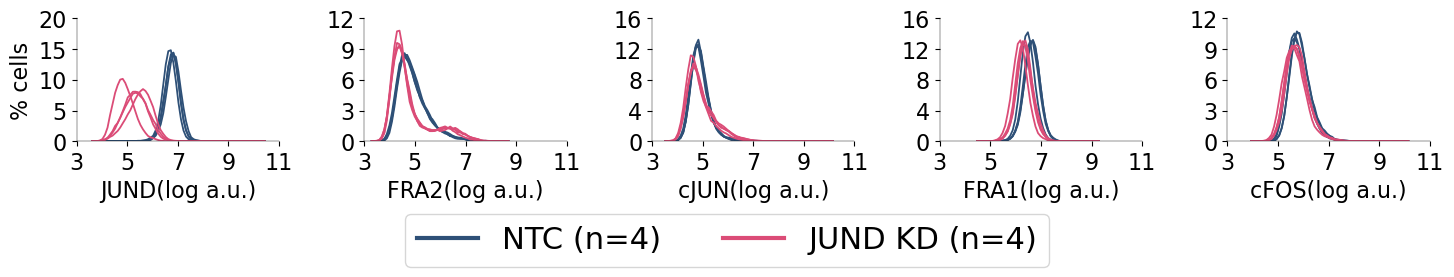

In [ ]:
def plot_protein_histogram_percent(
    data, proteins, condition1='NTC', condition2='JUND KD',
    save_plot = False,
    bin_method='scott', smooth=False, show_stats=True,
    group_col='Cell_line_name', replicate_col='Replicate_id',
    ntc_color='#2E5077', jund_kd_color='#DB4C77'
):
    # Validate proteins
    missing_proteins = [p for p in proteins if p not in data.columns]
    if missing_proteins:
        raise ValueError(f"Proteins not found in data: {missing_proteins}")
    
    fig, axes = plt.subplots(1, len(proteins), figsize=(15, 3), sharey=False)
    if len(proteins) == 1: axes = [axes]

    # Cosmetic global x-lims across panels
    # all_values = np.concatenate([_finite_numeric(data[p].values) for p in proteins]) if proteins else np.array([])
    # x_min, x_max = (all_values.min(), all_values.max()) if all_values.size else (0.0, 1.0)

    # Dynamic legend info
    nrep1 = data.loc[data[group_col]==condition1, replicate_col].nunique()
    nrep2 = data.loc[data[group_col]==condition2, replicate_col].nunique()

    # Plot each protein
    for idx, protein in enumerate(proteins):
        ax = axes[idx]
        edges = _bin_edges_for_protein(data[protein].values, bin_method, fine=(smooth is True))
        centers = (edges[:-1] + edges[1:]) / 2
        
        # Find ymax for this specific protein
        ymax_raw = 0.0
        for rep in data[replicate_col].dropna().unique():
            for cond in (condition1, condition2):
                x = _finite_numeric(data.loc[(data[group_col]==cond) & (data[replicate_col]==rep), protein].values)
                if x.size == 0: continue
                counts, _ = np.histogram(x, bins=edges)
                pct = 100.0 * counts / x.size
                if isinstance(smooth, int) and smooth > 1:
                    pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                    s = pct.sum()
                    if s > 0: pct *= (100.0 / s)
                if pct.size: ymax_raw = max(ymax_raw, pct.max())
        ymax = 1.1 * ymax_raw if ymax_raw > 0 else 10.0

        # Condition 1 replicates
        d1 = data.loc[data[group_col]==condition1, [replicate_col, protein]].dropna()
        for rep, sub in d1.groupby(replicate_col):
            x = _finite_numeric(sub[protein].values)
            if x.size == 0: continue
            counts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * counts / x.size
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0: pct *= (100.0 / s)
            if smooth:
                ax.plot(centers, pct, color=ntc_color, alpha=1, lw=1.3)
            else:
                ax.plot(centers, pct, color=ntc_color, alpha=1, lw=1.3, drawstyle='steps-mid')

        # Condition 2 replicates
        d2 = data.loc[data[group_col]==condition2, [replicate_col, protein]].dropna()
        for rep, sub in d2.groupby(replicate_col):
            x = _finite_numeric(sub[protein].values)
            if x.size == 0: continue
            counts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * counts / x.size
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0: pct *= (100.0 / s)
            if smooth:
                ax.plot(centers, pct, color=jund_kd_color, alpha=1, lw=1.3)
            else:
                ax.plot(centers, pct, color=jund_kd_color, alpha=1, lw=1.3, drawstyle='steps-mid')

        # Replicate-aware stats (avoid pooled-cell t-test)
        if show_stats:
            rep_meds_1 = d1.groupby(replicate_col)[protein].median()
            rep_meds_2 = d2.groupby(replicate_col)[protein].median()
            if rep_meds_1.size > 1 and rep_meds_2.size > 1:
                _, p = stats.ttest_ind(rep_meds_1, rep_meds_2, equal_var=False)
                stars = '***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
                ax.text(0.98, 0.95, stars, transform=ax.transAxes, ha='right', va='top',
                        fontsize=32, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # Styling
        ax.set_xlabel(f'{protein}(log a.u.)')
        # Set limits first
        ax.set_xlim(3, 11)               
        ax.set_xticks([3, 5, 7, 9, 11]) 
      
        # Set y-axis with exactly 5 evenly spaced ticks (excluding 0)
        ax.set_ylim(0, ymax)
        set_integer_ticks(ax, target_ticks=5)

        if idx == 0: ax.set_ylabel('% cells')
        for spine in ax.spines.values(): spine.set_linewidth(0.3)
        

    # Legend
    handles = [
        plt.Line2D([0], [0], color=ntc_color, lw=3, label=f'{condition1} (n={nrep1})'),
        plt.Line2D([0], [0], color=jund_kd_color, lw=3, label=f'{condition2} (n={nrep2})')
    ]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.45)
    # save figure as 300 dpi pdf
    if save_plot:
        figure_title = f'Histogram {condition1} vs {condition2} bin = {bin_method}'
        fig.savefig(f'{figure_title}.pdf', dpi=300, bbox_inches='tight', pad_inches=0.2)
    return fig


# 1. Histogram with Scott's rule for bin width (recommended)
fig = plot_protein_histogram_percent(
    df_clean_shRNA_1_rename, 
    ['JUND','FRA2','cJUN','FRA1','cFOS'],
    condition1='NTC', 
    condition2='JUND KD',
    bin_method=0.1,
    smooth=3,
    save_plot=True,  # or 'fd', 'sturges', or a fixed value like 0.1
    show_stats=False  # Since showing individual replicates
)


In [9]:
# print the number of replicates and cell lines
print(df_clean_shRNA_1_rename['Replicate_id'].nunique())
print(df_clean_shRNA_1_rename['Cell_line_name'].nunique())


4
17


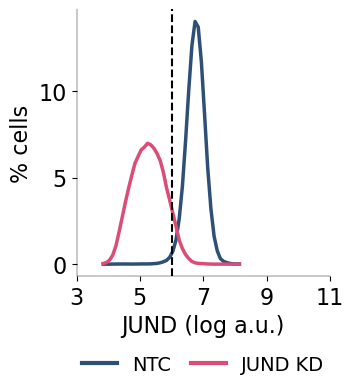

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

def plot_jund_histogram_percent(
    data,
    condition1='NTC',
    condition2='JUND KD',
    group_col='Cell_line_name',
    replicate_col='Replicate_id',
    threshold=6,
    bin_width=0.1,
    smooth=3,
    plot_mode='replicates',  # 'replicates' or 'pooled'
    ntc_color='#2E5077',
    jund_kd_color='#DB4C77'
):
    protein = 'JUND'

    plot_df = data[data[group_col].isin([condition1, condition2])].copy()
    edges = np.arange(plot_df[protein].min(), plot_df[protein].max() + bin_width, bin_width)
    centers = (edges[:-1] + edges[1:]) / 2

    fig, ax = plt.subplots(figsize=(4, 4))

    for cond, color in [(condition1, ntc_color), (condition2, jund_kd_color)]:
        d = plot_df.loc[plot_df[group_col] == cond, [replicate_col, protein]].dropna()

        if plot_mode == 'replicates':
            groups = d.groupby(replicate_col)
        elif plot_mode == 'pooled':
            groups = [(cond, d)]
        else:
            raise ValueError("plot_mode must be 'replicates' or 'pooled'")

        for _, sub in groups:
            x = sub[protein].dropna().values
            if x.size == 0:
                continue

            counts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * counts / x.size

            if smooth and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                pct *= 100.0 / pct.sum()

            alpha = 0.7 if plot_mode == 'replicates' else 1
            lw = 1.3 if plot_mode == 'replicates' else 2.5
            ax.plot(centers, pct, color=color, lw=lw, alpha=alpha)

    ax.axvline(threshold, color='black', linestyle='--', lw=1.5)

    ax.set_xlabel('JUND (log a.u.)')
    ax.set_ylabel('% cells')
    ax.set_xlim(3, 11)
    ax.set_xticks([3, 5, 7, 9, 11])

    handles = [
        plt.Line2D([0], [0], color=ntc_color, lw=3, label=condition1),
        plt.Line2D([0], [0], color=jund_kd_color, lw=3, label=condition2),
        #plt.Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'{threshold}')
    ]

    ax.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.23),
        ncol=3,
        frameon=False,
        fontsize=14,
        handlelength=1.8,
        columnspacing=1.0
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    return fig

# All individual replicates
# fig = plot_jund_histogram_percent(df_clean_shRNA_1_rename, plot_mode='replicates')
# plt.show()

# Pooled cells across replicates
fig = plot_jund_histogram_percent(df_clean_shRNA_1_rename, plot_mode='pooled')
# save the figure
fig.savefig('jund_histogram_percent_pooled.pdf', dpi=300, bbox_inches='tight')
plt.show()

#### Sample equal number of cells from each replicate for each Cell_line_name

In [19]:
# Initialize an empty list to store sampled DataFrames
rep_ids = df_clean_shRNA_1_rename['Replicate_id'].unique()
conditions = df_clean_shRNA_1_rename['Cell_line_name'].unique()
sampled_dfs = []

for rep_id in rep_ids:
    # Filter the dataframe for the current rep_id
    df_rep = df_clean_shRNA_1_rename[df_clean_shRNA_1_rename['Replicate_id'] == rep_id]
    
    rep_samples = []
    for condition in conditions:
        # Sample 100 cells from each condition (or all if less than 100)
        condition_df = df_rep[df_rep['Cell_line_name'] == condition]
        sample = condition_df.sample(n=min(750, len(condition_df)), replace=False, random_state=42)
        rep_samples.append(sample)
    
    # Combine the samples for this rep_id
    rep_sample = pd.concat(rep_samples)
    
    # Append to the list of sampled DataFrames
    sampled_dfs.append(rep_sample)

# Combine all sampled DataFrames
df_clean_shRNA_1_sampled = pd.concat(sampled_dfs, ignore_index=True)

# Print the shape of the new DataFrame
print(f"Shape of df_clean_shRNA_1_sampled: {df_clean_shRNA_1_sampled.shape}")

Shape of df_clean_shRNA_1_sampled: (51000, 15)


In [ ]:
df_clean_shRNA_1_sampled

#### Plot single cell density

In [ ]:
def plot_flow_cytometry(df, cell_lines=None, reference_cell_line='WT', 
                        x_column='cJUN', y_column='FRA2', 
                        n_replicates=4, figsize=(24, 22), cmap='jet',
                        fixed_gates=None):
    """
    Create flow cytometry scatter plots for specified cell lines with consistent gating.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing flow cytometry data with columns for Cell_line_name, 
        Replicate_id, and measurement columns.
    cell_lines : list, optional
        List of cell line names to plot. If None, all unique cell lines will be plotted.
    reference_cell_line : str, default='WT_1'
        Cell line to use for setting gates if fixed_gates is None.
    x_column : str, default='cJUN'
        Column name for x-axis.
    y_column : str, default='FRA2'
        Column name for y-axis.
    n_replicates : int, default=4
        Number of replicates to display (columns in the plot grid).
    figsize : tuple, default=(20, 18)
        Figure size as (width, height) in inches.
    cmap : str, default='jet'
        Colormap for the density plot.
    fixed_gates : tuple, optional
        (x_gate, y_gate) values for quadrant division. If None, will be calculated
        from the reference cell line.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object.
    """
    # If no cell lines specified, use all unique cell lines
    if cell_lines is None:
        cell_lines = df['Cell_line_name'].unique()
    
    n_cell_lines = len(cell_lines)
    
    # Create subplot grid
    fig, axes = plt.subplots(n_cell_lines, n_replicates, figsize=figsize)
    
    # For single cell line case, make axes 2D
    if n_cell_lines == 1:
        axes = axes.reshape(1, -1)
    
    # Calculate gates from reference cell line if fixed_gates not provided
    if fixed_gates is None:
        ref_data = df[df['Cell_line_name'] == reference_cell_line]
        
        # If reference cell line exists in data
        if not ref_data.empty:
            x_gate = np.median(ref_data[x_column].values)
            y_gate = np.median(ref_data[y_column].values)
        else:
            # Fallback to median of all data
            x_gate = np.median(df[x_column].values)
            y_gate = np.median(df[y_column].values)
            print(f"Warning: Reference cell line '{reference_cell_line}' not found. Using overall median for gates.")
    else:
        x_gate, y_gate = fixed_gates
    
    print(f"Using gates at x={x_gate:.2f}, y={y_gate:.2f}")
    
    # Process each cell line and replicate
    for i, cell_line in enumerate(cell_lines):
        for j in range(n_replicates):
            rep_id = j + 1  # Replicate IDs are 1-based
            
            # Filter data for this cell line and replicate
            subset = df[(df['Cell_line_name'] == cell_line) & 
                        (df['Replicate_id'] == rep_id)]
            
            if subset.empty:
                # If no data for this combination, display empty plot
                axes[i, j].text(0.5, 0.5, 'No Data', 
                                ha='center', va='center', transform=axes[i, j].transAxes)
                continue
            
            # Get x and y data
            x = subset[x_column].values
            y = subset[y_column].values
            
            # Remove any potential NaN or infinite values
            valid = np.isfinite(x) & np.isfinite(y)
            x, y = x[valid], y[valid]
            
            if len(x) < 10:  # Not enough points for density estimation
                axes[i, j].scatter(x, y, s=5, alpha=0.5)
                continue
            
            # Calculate point density using KDE
            xy = np.vstack([x, y])
            z = gaussian_kde(xy)(xy)
            
            # Sort points by density so denser points appear on top
            idx = z.argsort()
            x, y, z = x[idx], y[idx], z[idx]
            
            # Create scatter plot - using linear normalization since data is already in log format
            scatter = axes[i, j].scatter(
                x, y, c=z, s=5, cmap=cmap, alpha=0.8
            )
            
            # Add quadrant lines at the determined gate values
            axes[i, j].axhline(y=y_gate, color='black', linestyle='--', alpha=0.5)
            axes[i, j].axvline(x=x_gate, color='black', linestyle='--', alpha=0.5)
            
            # Calculate percentages in each quadrant using fixed gates
            q1 = 100 * np.sum((x < x_gate) & (y >= y_gate)) / len(x)  # Top-left
            q2 = 100 * np.sum((x >= x_gate) & (y >= y_gate)) / len(x)  # Top-right
            q3 = 100 * np.sum((x < x_gate) & (y < y_gate)) / len(x)   # Bottom-left
            q4 = 100 * np.sum((x >= x_gate) & (y < y_gate)) / len(x)  # Bottom-right
            
            # Add percentage annotations in corners (with red text)
            axes[i, j].text(0.05, 0.90, f"{q1:.1f}%", transform=axes[i, j].transAxes, 
                           color='red', fontweight='bold', fontsize=16)
            axes[i, j].text(0.85, 0.90, f"{q2:.1f}%", transform=axes[i, j].transAxes, 
                           color='red', fontweight='bold', fontsize=16)
            axes[i, j].text(0.05, 0.05, f"{q3:.1f}%", transform=axes[i, j].transAxes, 
                           color='red', fontweight='bold', fontsize=16)
            axes[i, j].text(0.85, 0.05, f"{q4:.1f}%", transform=axes[i, j].transAxes, 
                           color='red', fontweight='bold', fontsize=16)
            
            # Set title for each subplot
            if i == 0:
                axes[i, j].set_title(f'{cell_line} Rep {rep_id}', fontsize=16)
            else:
                axes[i, j].set_title(f'{cell_line} Rep {rep_id}', fontsize=16)
                
            # Add cell line name at the left of each row
            if j == 0:
                axes[i, j].text(-0.2, 0.5, cell_line, rotation=90, 
                               transform=axes[i, j].transAxes, va='center', ha='center',
                               fontsize=16, fontweight='bold')
            
            # Set fixed axis limits between 3 and 9
            axes[i, j].set_xlim(3, 9)
            axes[i, j].set_ylim(3, 9)
            
            # Set labels only for the outer plots
            if i == n_cell_lines - 1:
                axes[i, j].set_xlabel(x_column, fontsize=12)
            if j == 0:
                axes[i, j].set_ylabel(y_column, fontsize=12)
    
    # Adjust layout and add colorbar
    plt.tight_layout(h_pad=2, w_pad=1)
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    fig.colorbar(scatter, cax=cbar_ax, label='Density')
    
    return fig, (x_gate, y_gate)  # Return the gates as well for reference

# Example usage:
# 
# # Plot with gates based on WT_1 cell line
fixed_gates = (6, 6)
fig, gates = plot_flow_cytometry(df_clean_shRNA_1_rename, x_column='SOX10', y_column='MITF',
                                 cell_lines=['WT','NTC','JUND KD', 'cJUN KO + JUND KD'], 
                                fixed_gates=fixed_gates)

#'WT','FOS_B8S KO', 'FOS_D8S KO','FOS_B8S KO + JUND KD', 'FOS_D8S KO + JUND KD','JUND KD'
# 
# # Or use fixed gates for all plots
# fixed_gates = (5.0, 6.0)  # x_gate, y_gate values
# fig, _ = plot_flow_cytometry(df, cell_lines=['WT_1', 'FOS_B8S KO', 'FOS_D8S KO', 'JUND KD'],
#                            fixed_gates=fixed_gates)
# 
# plt.savefig('flow_cytometry_plots.png', dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
df_clean_shRNA_1_rename

In [ ]:
# export the sampled data to a csv file
#df_clean_shRNA_1_sampled.to_csv('20231114_natlog_single_cell_data_with_replicates_JUN_KO_A4_JUND_KD_sampled_with_cellStateMarkers.csv', index=False)

#### Plot distribution overlap of JUND KD in COLO858 cells

In [12]:
def calculate_distribution_overlap(data1, data2, num_points=1000):
    """
    Calculate overlap and knockdown efficiency using raw (un-transformed) data
    """
    # Convert from natural log back to raw values
    raw_data1 = np.exp(data1)
    raw_data2 = np.exp(data2)
    
    # Calculate knockdown efficiencies
    mean_efficiency = ((np.mean(raw_data1) - np.mean(raw_data2)) / np.mean(raw_data1)) * 100
    median_efficiency = ((np.median(raw_data1) - np.median(raw_data2)) / np.median(raw_data1)) * 100
    
    # For the distribution overlap, we'll still use log-transformed data
    min_x = min(data1.min(), data2.min())
    max_x = max(data1.max(), data2.max())
    x_range = np.linspace(min_x, max_x, num_points)
    
    # Compute KDE for both distributions
    kde1 = stats.gaussian_kde(data1)
    kde2 = stats.gaussian_kde(data2)
    
    # Evaluate densities
    pdf1 = kde1(x_range)
    pdf2 = kde2(x_range)
    
    # Calculate overlap coefficient
    overlap = np.minimum(pdf1, pdf2)
    overlap_coefficient = np.trapz(overlap, x_range)
    
    return {
        'overlap_coefficient': overlap_coefficient,
        'overlap_percentage': overlap_coefficient * 100,
        'x_range': x_range,
        'kde1': pdf1,
        'kde2': pdf2,
        'mean_efficiency': mean_efficiency,
        'median_efficiency': median_efficiency
    }


In [13]:
# Example usage:
ntc_data = df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'] == 'NTC']['JUND']
kd_data = df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'] == 'JUND KD']['JUND']

results = calculate_distribution_overlap(ntc_data, kd_data)


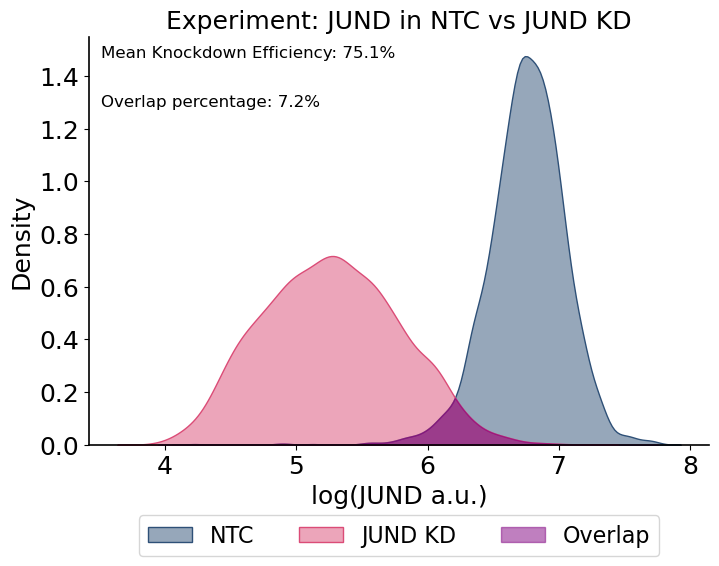

In [25]:
# Create visualization with overlap highlighted
plt.figure(figsize=(8, 6))

# Plot original distributions
sns.kdeplot(data=ntc_data, fill=True, alpha=0.5, label='NTC', color='#2E5077')
sns.kdeplot(data=kd_data, fill=True, alpha=0.5, label='JUND KD', color='#DB4C77')

# Highlight overlap area
plt.fill_between(results['x_range'], 
                 np.minimum(results['kde1'], results['kde2']),
                 alpha=0.5, color='purple', label='Overlap')

plt.xlabel('log(JUND a.u.)')
plt.ylabel('Density')
plt.title('Experiment: JUND in NTC vs JUND KD')

# Add efficiency and overlap percentage text
plt.text(0.02, 0.95, f'Mean Knockdown Efficiency: {results["mean_efficiency"]:.1f}%', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
         fontsize=12)
# plt.text(0.02, 0.89, f'Median Knockdown Efficiency: {results["median_efficiency"]:.1f}%', 
#          transform=plt.gca().transAxes,
#          bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
#          fontsize=12)
plt.text(0.02, 0.83, f'Overlap percentage: {results["overlap_percentage"]:.1f}%', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
         fontsize=12)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True)
plt.subplots_adjust(bottom=0.2)  # Add extra space at bottom for legend
# save figure as 300 dpi pdf
plt.savefig('S6_JUND_distribution_overlap_NTC_vs_JUND_KD.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
def plot_protein_distributions(df, proteins, primary_condition, title_prefix="Distribution of"):
    """
    Create KDE plots for specified proteins across different conditions.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The input DataFrame containing protein expression data
    proteins : str or list
        Single protein name or list of protein names to plot
    primary_condition : str
        The primary condition to highlight with a darker dashed line
    title_prefix : str, optional
        Prefix for the plot title
        
    Returns:
    --------
    None (displays the plots)
    """
    # Define control conditions and experimental conditions
    control_conditions = ['NTC', 'Cas9 + NTC', 'Cas9 KO + NTC']
    primary_condition = primary_condition  # The condition to highlight
    other_conditions = ['JUN KO + JUND KD', 'JUND KO + FOSL1 OE', 
                       'FOS_B8S KO + JUND KD', 'FOS_D8S KO + JUND KD']
    
    # Combined conditions list for plotting
    all_conditions = ['Control', primary_condition] + other_conditions
    
    # Create a temporary dataframe with a combined Control group
    # First, create a copy of the original dataframe to avoid modifying it
    temp_df = df.copy()
    
    # Identify rows that belong to any of the control conditions
    control_mask = temp_df['Cell_line_name'].isin(control_conditions)
    
    # Change the Cell_line_name to 'Control' for those rows
    temp_df.loc[control_mask, 'Cell_line_name'] = 'Control'
    
    # Filter to only include the conditions we want to plot
    plot_conditions = ['Control', primary_condition] + other_conditions
    temp_df = temp_df[temp_df['Cell_line_name'].isin(plot_conditions)]
    
    # Convert single protein input to list for consistent handling
    if isinstance(proteins, str):
        proteins = [proteins]
    
    # Set up the plotting style with distinct colors
    # First color for Control, special style for primary_condition, and other colors for the rest
    colors = ['#2E5077', '#000000', '#DB4C77', '#7CB342', '#FFA000', '#9C27B0', '#795548']  # Add more if needed
    
    # Create subplots for each protein
    fig, axes = plt.subplots(1, len(proteins), figsize=(8*len(proteins), 5))
    if len(proteins) == 1:
        axes = [axes]  # Make axes iterable when there's only one subplot
    
    for ax, protein in zip(axes, proteins):
        # Plot distribution for each condition
        for idx, condition in enumerate(plot_conditions):
            condition_data = temp_df[temp_df['Cell_line_name'] == condition][protein]
            
            if condition == primary_condition:
                # Highlight the primary condition with a thicker, dashed, darker line
                sns.kdeplot(data=condition_data, 
                           fill=False, 
                           alpha=1.0, 
                           label=condition, 
                           color=colors[1],  # Black color for primary condition
                           linestyle='--',   # Dashed line
                           linewidth=2.5,    # Thicker line
                           ax=ax)
            else:
                # Regular styling for other conditions
                sns.kdeplot(data=condition_data, 
                           fill=False, 
                           alpha=0.9, 
                           label=condition, 
                           color=colors[0] if condition == 'Control' else colors[idx+1],
                           ax=ax)
        
        # Add vertical dashed line at x=6 for the threshold
        ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.5, alpha=0.9)
        
        # Add annotation for the threshold line
        ax.text(6.05, ax.get_ylim()[1]*0.95, 'Threshold (x=6)', 
                rotation=90, va='top', fontsize=8, color='gray')
        
        # Set x-axis limits from 4 to 8
        ax.set_xlim(2, 8)
        
        # Customize the subplot
        ax.set_xlabel(f'{protein} log (a.u.)')
        #ax.set_ylabel('Density', fontsize=16)
        #ax.set_title(f'{title_prefix} {protein}', fontsize=14, fontweight='bold')
        
        # Add compact legend on the right side
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), 
                  fontsize=10, frameon=True, framealpha=0.8)
        
        # Add grid for better readability
        # ax.grid(alpha=0.2)
    
    plt.tight_layout()
    # save as high res pdf
    plt.savefig(f'{protein}_distribution_plot_COLO858_JUND_KD_experiment.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function with FRA2 and JUND KD as the primary condition
plot_protein_distributions(df_clean_shRNA_1_sampled, 
                         proteins='FRA2', 
                         primary_condition='JUND KD',
                         title_prefix="Distribution of")

# For multiple proteins, you can use:
# plot_protein_distributions(df_clean_shRNA_1_sampled,
#                          proteins=['FRA2', 'cFOS', 'JUNB'],
#                          primary_condition='JUND KD')

#### Figures 7J-K

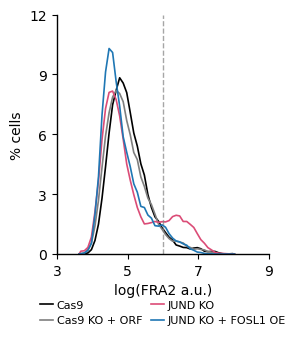

In [33]:
def _finite_numeric(a):
    """
    Return a 1D float ndarray with only finite values.
    Works for lists/Series/ndarrays and silently coerces strings to numeric.
    """
    x = pd.to_numeric(np.asarray(a).ravel(), errors='coerce')  # coerce non-numerics to NaN
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def plot_protein_distributions_percent(
    data, proteins,
    controls,                 # [control1, control2]
    perturbations,            # [pert1, pert2]
    *,
    save_plot=False,
    bin_method='scott',       # 'scott' | 'fd' | 'sturges' | 'auto' | float bin width
    smooth=False,             # False | True (fine bins=0.02) | int (moving-average window; renorm to 100)
    show_replicates=False,    # thin per-replicate lines
    show_stats=False,         # Welch t on replicate medians (pert vs control)
    group_col='Cell_line_name',
    replicate_col='Replicate_id',
    style='line'              # 'line' (padded to 0 at ends) or 'step'
):
    # ---- validate proteins ----
    if isinstance(proteins, str):
        proteins = [proteins]
    missing = [p for p in proteins if p not in data.columns]
    if missing:
        raise ValueError(f"Proteins not found in data: {missing}")

    # ---- validate conditions (take first two of each) ----
    if len(controls) < 2 or len(perturbations) < 2:
        raise ValueError("Pass at least two controls and two perturbations.")
    c1, c2 = controls[0], controls[1]
    p1, p2 = perturbations[0], perturbations[1]
    selected = [c1, c2, p1, p2]

    # colors by role
    color_map = {c1: '#000000', c2: '#7f7f7f', p1: '#DB4C77', p2: '#1f77b4'}

    # restrict to selected conditions
    df = data.loc[data[group_col].isin(selected)].copy()

    # figure scaffold
    fig, axes = plt.subplots(1, len(proteins), figsize=(3, 2), sharey=False) 
    if len(proteins) == 1:
        axes = [axes]

    # Get global x-limits for consistent x-axis ticks
    all_values = np.concatenate([_finite_numeric(df[p].values) for p in proteins]) if proteins else np.array([])
    x_min, x_max = (all_values.min(), all_values.max()) if all_values.size else (0.0, 1.0)

    # legend info (rep counts)
    rep_counts = {cond: df.loc[df[group_col]==cond, replicate_col].nunique() for cond in selected}

    # Plot each protein with individual y-axis scaling
    for ax, protein in zip(axes, proteins):
        edges = _bin_edges_for_protein(df[protein].values, bin_method, fine=(smooth is True))
        centers = (edges[:-1] + edges[1:]) / 2.0

        # Find ymax for this specific protein
        ymax_raw = 0.0
        for cond in selected:
            x = _finite_numeric(df.loc[df[group_col] == cond, protein].values)
            if x.size == 0: 
                continue
            cts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * cts / max(1, x.size)
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0:
                    pct *= (100.0 / s)
            if pct.size:
                ymax_raw = max(ymax_raw, np.nanmax(pct))
            if show_replicates:
                for _, g in df.loc[df[group_col]==cond, [replicate_col, protein]].dropna().groupby(replicate_col):
                    xr = _finite_numeric(g[protein].values)
                    if xr.size == 0:
                        continue
                    c_rep, _ = np.histogram(xr, bins=edges)
                    pct_rep = 100.0 * c_rep / max(1, xr.size)
                    if isinstance(smooth, int) and smooth > 1:
                        pct_rep = uniform_filter1d(pct_rep, size=smooth, mode='nearest')
                        s = pct_rep.sum()
                        if s > 0:
                            pct_rep *= (100.0 / s)
                    if pct_rep.size:
                        ymax_raw = max(ymax_raw, np.nanmax(pct_rep))

        # Set fixed ymax to 12 for consistent spacing
        ymax = 12

        for cond in [c1, c2, p1, p2]:
            col = color_map[cond]
            x = _finite_numeric(df.loc[df[group_col]==cond, protein].values)
            cts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * cts / max(1, x.size)
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0:
                    pct *= (100.0 / s)

            # optional thin replicate lines
            if show_replicates:
                for _, g in df.loc[df[group_col]==cond, [replicate_col, protein]].dropna().groupby(replicate_col):
                    xr = _finite_numeric(g[protein].values)
                    if xr.size == 0: 
                        continue
                    c_rep, _ = np.histogram(xr, bins=edges)
                    pct_rep = 100.0 * c_rep / max(1, xr.size)
                    if isinstance(smooth, int) and smooth > 1:
                        pct_rep = uniform_filter1d(pct_rep, size=smooth, mode='nearest')
                        s = pct_rep.sum()
                        if s > 0:
                            pct_rep *= (100.0 / s)
                    if style == 'step':
                        ax.step(edges, np.r_[pct_rep, 0.0], where='post', color=col, alpha=0.25, lw=1.2)
                    else:
                        x_line = np.r_[edges[0], centers, edges[-1]]
                        y_line = np.r_[0.0, pct_rep, 0.0]
                        ax.plot(x_line, y_line, color=col, alpha=0.8, lw=1.2)

            # pooled curve
            label = f"{cond}"
            if style == 'step':
                ax.step(edges, np.r_[pct, 0.0], where='post', color=col, lw=1.2, label=label)
            else:
                x_line = np.r_[edges[0], centers, edges[-1]]  # pad ends so it hits 0
                y_line = np.r_[0.0, pct, 0.0]
                ax.plot(x_line, y_line, color=col, lw=1.2, label=label)

        # optional replicate-aware stats (pert vs control on replicate medians)
        if show_stats:
            stars_map = {}
            def rep_meds(cond):
                g = df.loc[df[group_col]==cond, [replicate_col, protein]].dropna()
                return g.groupby(replicate_col)[protein].median() if not g.empty else None
            for a in [p1, p2]:
                for b in [c1, c2]:
                    A, B = rep_meds(a), rep_meds(b)
                    if A is not None and B is not None and len(A)>1 and len(B)>1:
                        _, p = stats.ttest_ind(A, B, equal_var=False)
                        stars = '***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
                        stars_map[(a,b)] = stars
            if stars_map:
                txt = ", ".join([f"{k[0]} vs {k[1]}: {v}" for k,v in stars_map.items()])
                ax.text(0.98, 0.95, txt, transform=ax.transAxes, ha='right', va='top',
                        fontsize=9, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # axes cosmetics
        ax.set_xlabel(f'log({protein} a.u.)')
        ax.set_ylabel('% cells')
        ax.set_xlim(x_min, x_max)  # Use global x-limits
        #ax.set_ylim(bottom=0, top=ymax)
        
        # Set exactly 4 integer ticks on x-axis
        ax.set_xlim(3, 9)               
        ax.set_xticks([3, 5, 7, 9]) 
        
        # Set y-axis with fixed ticks for perfect spacing
        ax.set_ylim(0, ymax)
        set_integer_ticks(ax, target_ticks=5)

        # Add horizontal dashed line at y=6
        ax.axvline(x=6, color='gray', linestyle='--', alpha=0.7, linewidth=1)
       
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black') 
        ax.spines['top'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.0)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['top'].set_linewidth(1.0) 
        ax.spines['right'].set_linewidth(1.0)
        
        # Also set tick colors to black
        ax.tick_params(colors='black', which='both')
        ax.xaxis.label.set_color('black')
        ax.yaxis.label.set_color('black')
        
        ax.legend(frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
         fontsize=8, columnspacing=0.8, handlelength=1.2, handletextpad=0.3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=-0.3)
    if save_plot:
        fname = f"Histogram_4conditions_{'+'.join([c1,c2,p1,p2])}_bin={bin_method}_{style}.pdf"
        fig.savefig(fname, dpi=300, bbox_inches='tight', pad_inches=0.2)

    return fig

# Example usage with your data:

fig = plot_protein_distributions_percent(
    df_clean_shRNA_1_sampled,
    proteins='FRA2',
    controls=['Cas9', 'Cas9 KO + ORF'],  # Will be black and grey
    perturbations=['JUND KO', 'JUND KO + FOSL1 OE'],  # Will be red and blue
    bin_method=0.1,
    smooth=3,
    style = 'line',
    save_plot=True,
    show_replicates=False
)

In [34]:
# print each cell line name
print(df_clean_shRNA_1_rename['Cell_line_name'].unique())


['WT' 'Cas9' 'cJUN KO' 'FOS_B8S KO' 'JUND KO' 'FOS_D8S KO'
 'JUND KO + FOSL1 OE' 'Positive ORF' 'Cas9 KO + ORF' 'NTC' 'FOSL1 OE'
 'Cas9 KO + NTC' 'JUN OE' 'FOS_B8S KO + JUND KD' 'FOS_D8S KO + JUND KD'
 'JUND KD' 'cJUN KO + JUND KD']


In [34]:
from scipy import stats
def plot_percent_high_bar(
    data, protein, threshold=6.8,
    controls=('NTC','Cas9 KO + NTC'),
    perturbations=('JUND KD','cJUN KO + JUND KD'),
    *,
    group_col='Cell_line_name',
    replicate_col='Replicate_id',
    show_points=True,          # show per-replicate dots
    figsize=(4, 4),
    save_plot=False,
    filename=None,
    # NEW: list of tuples of condition names to compare & annotate
    comparisons=None,
    show_ns=True               # match your violin behavior
):
    """
    Bar plot of % {protein}-high cells (>= threshold) for 4 conditions.
    Height = mean across replicates; error bar = SEM across replicates.

    If `comparisons` is provided (e.g., [('NTC','JUND KD'), ('JUND KD','cJUN KO + JUND KD')]),
    performs Welch's t-tests on replicate-level %high and annotates p-values on the plot.
    """

    # ---- helpers (mirror your violin formatting) ----
    def _sem(s):
        s = np.asarray(s, dtype=float)
        return np.std(s, ddof=1)/np.sqrt(len(s)) if len(s) > 1 else np.nan

    def p_to_text(p: float) -> str:
        if p < 0.05:
            return f"p = {p:.1e}"
        else:
            return f"p = {p:.2f}" if show_ns else ""

    def add_sig_bar(ax, x0, x1, y, h, text, color="black", lw=1.2, fontsize=12):
        ax.plot([x0, x0, x1, x1], [y, y+h, y+h, y], c=color, lw=lw)
        ax.text((x0 + x1) / 2.0, y + h, text, ha="center", va="bottom",
                color=color, fontsize=fontsize)

    # order + colors
    conds = [controls[0], controls[1], perturbations[0], perturbations[1]]
    colors = {conds[0]:'#000000', conds[1]:'#7f7f7f', conds[2]:'#DB4C77', conds[3]:'#1f77b4'}

    # subset to selected conditions
    df = data.loc[data[group_col].isin(conds), [group_col, replicate_col, protein]].copy()

    # ---- compute replicate-level % high ----
    rows = []
    for cond, g_cond in df.groupby(group_col):
        for rep, g_rep in g_cond.groupby(replicate_col):
            x = g_rep[protein].to_numpy()
            x = x[np.isfinite(x)]
            if x.size == 0:
                continue
            pct_high = 100.0 * np.mean(x >= threshold)  # percent of cells >= threshold in that replicate
            rows.append({'condition': cond, 'replicate': rep, 'percent_high': pct_high, 'n_cells': x.size})
    rep_df = pd.DataFrame(rows)

    if rep_df.empty:
        raise ValueError("No finite values found for the selected protein/conditions.")

    # ---- summary (replicate is the unit) ----
    summary = (rep_df
               .groupby('condition', sort=False)['percent_high']
               .agg(mean='mean', sem=_sem, n_reps='size')
               .reindex(conds))

    # ---- plot ----
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    x = np.arange(len(conds))

    bars = ax.bar(
        x,
        summary['mean'].values,
        yerr=summary['sem'].values,
        capsize=4,
        color=[colors[c] for c in conds],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
        width=0.5
    )

    # optional per-replicate points (jittered)
    if show_points:
        rng = np.random.default_rng(0)
        for i, cond in enumerate(conds):
            vals = rep_df.loc[rep_df['condition']==cond, 'percent_high'].to_numpy()
            jit = (rng.random(len(vals)) - 0.5) * 0.20
            ax.scatter(i + jit, vals, s=32, color='white', edgecolor='black', zorder=3)

    # cosmetics
    ax.set_ylabel(f'% {protein}$^{{high}}$')
    # line breaks after ' + '
    label_conds = [cond.replace(' + ', '\n+\n') for cond in conds]
    ax.set_xticks(x, label_conds, ha='center')

    # Dynamic y-axis limits and ticks
# Dynamic y-axis limits and ticks
# Dynamic y-axis limits and ticks
    top = np.nanmax(summary['mean'].values + np.nan_to_num(summary['sem'].values))
    ylim_max = max(5, top) * 1.20
    ax.set_ylim(0, ylim_max)

    # Create exactly 5 evenly spaced integer ticks
    # Find a nice maximum that's close to ylim_max but gives clean spacing
    nice_max = int(np.ceil(top)) + 1  # Round up the data max and add 1 for padding
    if nice_max % 4 != 0:  # Ensure it's divisible by 4 for clean spacing
        nice_max = ((nice_max // 4) + 1) * 4

    step = nice_max // 4
    y_ticks = [0, step, 2*step, 3*step, 4*step]
    ax.set_yticks(y_ticks)

    # Adjust ylim to accommodate the nice ticks
    ax.set_ylim(0, nice_max * 1.1)
    # ---- Welch t-tests + p-value bars (if requested) ----
    if comparisons:
        # Build a mapping from condition -> x-position
        xpos = {c: i for i, c in enumerate(conds)}

        # Base height for annotations
        current_ymax = ax.get_ylim()[1]
        data_tops = summary['mean'].values + np.nan_to_num(summary['sem'].values)
        base = max(current_ymax, float(np.nanmax(data_tops)))
        y_range = base if base > 0 else 1.0
        step = 0.08 * y_range
        hbar = 0.02 * y_range
        next_y = base + 0.05 * y_range

        for idx, (a, b) in enumerate(comparisons):
            if a not in xpos or b not in xpos:
                continue
            xa, xb = xpos[a], xpos[b]

            ga = rep_df.loc[rep_df['condition'] == a, 'percent_high'].to_numpy()
            gb = rep_df.loc[rep_df['condition'] == b, 'percent_high'].to_numpy()
            ga = ga[np.isfinite(ga)]
            gb = gb[np.isfinite(gb)]

            if len(ga) >= 2 and len(gb) >= 2:
                # Welch's t-test
                tstat, pval = stats.ttest_ind(ga, gb, equal_var=False)
                ptxt = p_to_text(pval)
                if ptxt or show_ns:
                    # stagger bars a bit to avoid collisions
                    y = next_y + (idx % 2) * (0.6 * step)
                    # Make p-value text font size bigger by passing fontsize argument
                    add_sig_bar(
                        ax, 
                        x0=xa, 
                        x1=xb, 
                        y=y, 
                        h=hbar, 
                        text=ptxt if ptxt else "p = {:.2f}".format(pval),
                        fontsize=16  # <-- increase font size here
                    )
                    # update ylim if needed
                    ax.set_ylim(ax.get_ylim()[0], max(ax.get_ylim()[1], y + hbar + 0.06 * y_range))

    plt.tight_layout()
    if save_plot:
        if filename is None:
            filename = f"{protein}_percent_high_thresh_{threshold}.pdf"
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    return fig, rep_df, summary

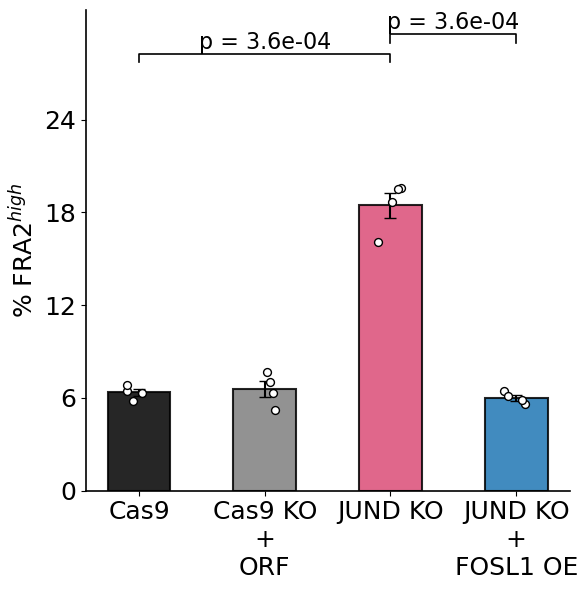

In [39]:
# uncomment one of the following two
# fig, rep_df, summary = plot_percent_high_bar(
#     df_clean_shRNA_1_rename,
#     protein='FRA2',
#     threshold=6,
#     controls=['NTC', 'Cas9 KO + NTC'],                 # black, grey
#     perturbations=['JUND KD', 'cJUN KO + JUND KD'],    # red, blue
#     group_col='Cell_line_name',
#     replicate_col='Replicate_id',
#     show_points=True,    # dots = each replicate’s % high
#     figsize=(6, 6),
#     save_plot=True,
#     comparisons=[('NTC', 'JUND KD'), ('JUND KD', 'cJUN KO + JUND KD')]
# )

fig, rep_df, summary = plot_percent_high_bar(
    df_clean_shRNA_1_rename,
    protein='FRA2',
    threshold=6,
    controls=['Cas9', 'Cas9 KO + ORF'],  # Will be black and grey
    perturbations=['JUND KO', 'JUND KO + FOSL1 OE'],  # red, blue
    group_col='Cell_line_name',
    replicate_col='Replicate_id',
    show_points=True,    # dots = each replicate’s % high
    figsize=(6, 6),
    save_plot=True,
    comparisons=[('Cas9', 'JUND KO'), ('JUND KO', 'JUND KO + FOSL1 OE')]
)

#### Figures 7B, 7L

In [ ]:
def plot_perturbation_flow_cytometry_v3(df: pd.DataFrame,
                                      figure_conditions: Dict[str, List[str]],
                                      x_column: str = 'MITF',
                                      y_column: str = 'SOX10', 
                                      condition_col: str = 'Cell_line_name',
                                      replicate_col: str = 'Replicate_id',
                                      x_gate: float = 6.0,
                                      y_gate: float = 6.0,
                                      figsize: Tuple[int, int] = (15, 5),
                                      cmap: str = 'jet',
                                      save_pdf: bool = True,
                                      save_dir: str = 'perturbation_flow_plots',
                                      dpi: int = 300) -> Dict:
    """
    Plot flow cytometry data for perturbation experiments with statistical comparisons.
    
    VERSION 3 - Fixed p-value calculations and debugging
    """
    
    print("=== USING VERSION 3 WITH BLACK P-VALUES AND WELCH T-TEST DEBUGGING ===")

    def _sem(vals):
        """Standard error of the mean. ddof=1 (sample SD). NaN if <2 replicates."""
        vals = np.asarray(vals, dtype=float)
        n = len(vals)
        if n < 2:
            return np.nan
        return np.std(vals, ddof=1) / np.sqrt(n)

    # Create save directory if needed
    if save_pdf:
        try:
            os.makedirs(save_dir, exist_ok=True)
            print(f"Successfully created/verified directory: {save_dir}/")
        except Exception as e:
            print(f"Error creating directory: {e}")
            save_pdf = False
    
    # Store all figures and results
    results = {'figures': {}, 'statistics': {}}
    
    # Create each figure
    for fig_name, conditions in figure_conditions.items():
        print(f"\nCreating {fig_name} with conditions: {conditions}")
        
        # Filter data for these conditions
        plot_df = df[df[condition_col].isin(conditions)].copy()
        
        if plot_df.empty:
            print(f"Warning: No data found for conditions {conditions}")
            continue
        
        # Create figure with 3 subplots (1 row, 3 columns)
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Store quadrant percentages for statistical testing
        condition_quadrants = {}
        
        # Plot each condition
        for i, condition in enumerate(conditions):
            print(f"  Processing condition: {condition}")
            
            # Get data for this condition
            condition_data = plot_df[plot_df[condition_col] == condition]
            
            if condition_data.empty:
                axes[i].text(0.5, 0.5, 'No Data', 
                           ha='center', va='center', transform=axes[i].transAxes,
                           fontsize=12)
                axes[i].set_xlim(4, 9)
                axes[i].set_ylim(4, 9)
                continue
            
            # Get all cells for density plotting
            x = condition_data[x_column].values
            y = condition_data[y_column].values
            
            # Remove NaN or infinite values
            valid = np.isfinite(x) & np.isfinite(y)
            x, y = x[valid], y[valid]
            
            if len(x) < 10:
                axes[i].scatter(x, y, s=5, alpha=0.5)
            else:
                # Calculate point density using KDE
                xy = np.vstack([x, y])
                z = gaussian_kde(xy)(xy)
                
                # Normalize density to [0, 1] range for color mapping
                z = (z - z.min()) / (z.max() - z.min())
                
                # Sort points by density so denser points appear on top
                idx = z.argsort()
                x, y, z = x[idx], y[idx], z[idx]
                
                # Create scatter plot with density coloring
                scatter = axes[i].scatter(
                    x, y, c=z, s=5, cmap=cmap, alpha=0.8, vmin=0, vmax=1
                )
            
            # Add quadrant lines
            axes[i].axhline(y=y_gate, color='black', linestyle='--', alpha=0.5)
            axes[i].axvline(x=x_gate, color='black', linestyle='--', alpha=0.5)
            
            # Calculate quadrant percentages per replicate
            replicate_quadrants = {
                'bottom_left': [],   # x < gate, y < gate
                'bottom_right': [],  # x >= gate, y < gate  
                'top_left': [],      # x < gate, y >= gate
                'top_right': []      # x >= gate, y >= gate
            }
            
            for rep_id in condition_data[replicate_col].unique():
                rep_data = condition_data[condition_data[replicate_col] == rep_id]
                rep_x = rep_data[x_column].values
                rep_y = rep_data[y_column].values
                
                # Remove NaN/inf for this replicate
                valid_rep = np.isfinite(rep_x) & np.isfinite(rep_y)
                rep_x, rep_y = rep_x[valid_rep], rep_y[valid_rep]
                
                if len(rep_x) > 0:
                    total_cells = len(rep_x)
                    
                    # Calculate percentages for each quadrant
                    bottom_left = 100 * np.sum((rep_x < x_gate) & (rep_y < y_gate)) / total_cells
                    bottom_right = 100 * np.sum((rep_x >= x_gate) & (rep_y < y_gate)) / total_cells
                    top_left = 100 * np.sum((rep_x < x_gate) & (rep_y >= y_gate)) / total_cells
                    top_right = 100 * np.sum((rep_x >= x_gate) & (rep_y >= y_gate)) / total_cells
                    
                    replicate_quadrants['bottom_left'].append(bottom_left)
                    replicate_quadrants['bottom_right'].append(bottom_right)
                    replicate_quadrants['top_left'].append(top_left)
                    replicate_quadrants['top_right'].append(top_right)
            
            # Store for statistical testing
            condition_quadrants[condition] = replicate_quadrants
            
            # Debug: print replicate info
            print(f"    {condition}: {len(replicate_quadrants['bottom_left'])} replicates")
            print(f"    Bottom-left percentages: {replicate_quadrants['bottom_left']}")
            
            # Calculate mean ± SEM percentages for display
            if replicate_quadrants['bottom_left']:
                n_rep = len(replicate_quadrants['bottom_left'])

                def _fmt(quad):
                    vals = replicate_quadrants[quad]
                    m = np.mean(vals)
                    e = _sem(vals)
                    return f"{m:.1f}%" if np.isnan(e) else f"{m:.1f}±{e:.1f}%"

                # Display quadrant percentages as mean±SEM - ALL IN RED, FONT SIZE 10
                axes[i].text(0.05, 0.35, _fmt('bottom_left'),
                           transform=axes[i].transAxes,
                           color='red', fontweight='bold', fontsize=10,
                           ha='left', va='bottom')   # Bottom-left

                axes[i].text(0.95, 0.35, _fmt('bottom_right'),
                           transform=axes[i].transAxes,
                           color='red', fontweight='bold', fontsize=10,
                           ha='right', va='bottom')  # Bottom-right

                axes[i].text(0.05, 0.95, _fmt('top_left'),
                           transform=axes[i].transAxes,
                           color='red', fontweight='bold', fontsize=10,
                           ha='left', va='top')      # Top-left

                axes[i].text(0.95, 0.95, _fmt('top_right'),
                           transform=axes[i].transAxes,
                           color='red', fontweight='bold', fontsize=10,
                           ha='right', va='top')      # Top-right
            
            # Set axis properties
            axes[i].set_xlim(4, 9)
            axes[i].set_ylim(4, 9)

            # Custom tick formatting
            ticks = np.linspace(4, 9, 6)
            axes[i].set_xticks(ticks)
            axes[i].set_yticks(ticks)
            
            tick_labels = ['4', '5', '6', '7', '8', '9']
            axes[i].set_xticklabels(tick_labels)
            axes[i].set_yticklabels(tick_labels)
            
            # Labels
            axes[i].set_xlabel(f'log ({x_column} a.u.)')
            if i == 0:
                axes[i].set_ylabel(f'log ({y_column} a.u.)')
            
            # Condition title
            axes[i].set_title(condition, fontsize=16, pad=20)
        
        # P-VALUE CALCULATIONS WITH DEBUGGING
        fig_stats = {}
        
        # Compare condition 0 vs 1
        if (conditions[0] in condition_quadrants and 
            conditions[1] in condition_quadrants and
            condition_quadrants[conditions[0]]['bottom_left'] and 
            condition_quadrants[conditions[1]]['bottom_left']):
            
            group1 = condition_quadrants[conditions[0]]['bottom_left']
            group2 = condition_quadrants[conditions[1]]['bottom_left']
            
            print(f"\nP-value calculation: {conditions[0]} vs {conditions[1]}")
            print(f"Group 1 ({conditions[0]}): {group1}")
            print(f"Group 2 ({conditions[1]}): {group2}")
            
            try:
                # Check for valid data
                if len(group1) < 2 or len(group2) < 2:
                    print(f"Warning: Not enough replicates for t-test (need ≥2 each)")
                    p_text = "p = N/A"
                elif np.var(group1) == 0 and np.var(group2) == 0:
                    print(f"Warning: No variance in either group")
                    p_text = "p = N/A"
                else:
                    stat, p_val_01 = ttest_ind(group1, group2, equal_var=False)  # Welch t-test
                    fig_stats[f"{conditions[0]}_vs_{conditions[1]}"] = p_val_01
                    
                    print(f"T-statistic: {stat}, P-value: {p_val_01}")
                    
                    # Handle edge cases
                    if np.isnan(p_val_01) or np.isinf(p_val_01):
                        p_text = "p = N/A"
                    elif p_val_01 < 1e-100:  # Very small p-values
                        p_text = "p < 1e-100"
                    else:
                        p_text = f"p = {p_val_01:.2e}"
                
                # Display p-value in BLACK
                fig.text(0.37, 0.02, p_text, ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')
                
            except Exception as e:
                print(f"Error calculating p-value for {conditions[0]} vs {conditions[1]}: {e}")
                fig.text(0.37, 0.02, "p = Error", ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')
        
        # Compare condition 1 vs 2  
        if (conditions[1] in condition_quadrants and 
            conditions[2] in condition_quadrants and
            condition_quadrants[conditions[1]]['bottom_left'] and 
            condition_quadrants[conditions[2]]['bottom_left']):
            
            group1 = condition_quadrants[conditions[1]]['bottom_left']
            group2 = condition_quadrants[conditions[2]]['bottom_left']
            
            print(f"\nP-value calculation: {conditions[1]} vs {conditions[2]}")
            print(f"Group 1 ({conditions[1]}): {group1}")
            print(f"Group 2 ({conditions[2]}): {group2}")
            
            try:
                # Check for valid data
                if len(group1) < 2 or len(group2) < 2:
                    print(f"Warning: Not enough replicates for t-test (need ≥2 each)")
                    p_text = "p = N/A"
                elif np.var(group1) == 0 and np.var(group2) == 0:
                    print(f"Warning: No variance in either group")
                    p_text = "p = N/A"
                else:
                    stat, p_val_12 = ttest_ind(group1, group2, equal_var=False)  # Welch t-test
                    fig_stats[f"{conditions[1]}_vs_{conditions[2]}"] = p_val_12
                    
                    print(f"T-statistic: {stat}, P-value: {p_val_12}")
                    
                    # Handle edge cases
                    if np.isnan(p_val_12) or np.isinf(p_val_12):
                        p_text = "p = N/A"
                    elif p_val_12 < 1e-100:  # Very small p-values
                        p_text = "p < 1e-100"
                    else:
                        p_text = f"p = {p_val_12:.2e}"
                
                # Display p-value in BLACK
                fig.text(0.63, 0.02, p_text, ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')
                
            except Exception as e:
                print(f"Error calculating p-value for {conditions[1]} vs {conditions[2]}: {e}")
                fig.text(0.63, 0.02, "p = Error", ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')
        
        # Set main title
        # fig.suptitle(f'{fig_name}: {x_column} vs {y_column}', 
        #             fontsize=18, fontweight='bold', y=0.95)
        
        # Adjust layout with bottom margin for p-values
        plt.tight_layout(pad=1.0, h_pad=0.5, w_pad=0.5)
        plt.subplots_adjust(bottom=0.15)  # Make room for p-values
        
        # Add colorbar (only to first figure)
        if fig_name == list(figure_conditions.keys())[0]:
            # Find a scatter plot for colorbar
            scatter_for_colorbar = None
            for ax in axes:
                for child in ax.get_children():
                    if hasattr(child, 'get_array') and child.get_array() is not None:
                        scatter_for_colorbar = child
                        break
                if scatter_for_colorbar is not None:
                    break
            
            if scatter_for_colorbar is not None:
                fig.subplots_adjust(right=0.85)
                cbar_ax = fig.add_axes([0.87, 0.25, 0.02, 0.5])
                cbar = fig.colorbar(scatter_for_colorbar, cax=cbar_ax, 
                                  label='Density', orientation='vertical')
                cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
                cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
        
        # Save figure
        if save_pdf:
            filename = f"{fig_name}_{x_column}_vs_{y_column}.pdf"
            filepath = os.path.join(save_dir, filename)
            fig.savefig(filepath, dpi=dpi, bbox_inches='tight', format='pdf')
            print(f"Saved: {filepath}")
        
        # Store results
        results['figures'][fig_name] = fig

        # Per-condition mean ± SEM for every quadrant (for export/records)
        summary = {}
        for cond, quads in condition_quadrants.items():
            summary[cond] = {
                q: {'mean': float(np.mean(v)),
                    'sem': float(_sem(v)),
                    'n': len(v)}
                for q, v in quads.items()
            }

        results['statistics'][fig_name] = {
            'quadrant_data': condition_quadrants,
            'p_values': fig_stats,
            'summary_mean_sem': summary,
        }
    
    print(f"\nGenerated {len(results['figures'])} figures")
    if save_pdf:
        print(f"All figures saved in '{save_dir}/' at {dpi} DPI")
    
    return results

=== USING VERSION 3 WITH BLACK P-VALUES AND WELCH T-TEST DEBUGGING ===
Successfully created/verified directory: perturbation_flow_plots/

Creating Figure1 with conditions: ['NTC', 'JUND KD', 'cJUN KO + JUND KD']
  Processing condition: NTC
    NTC: 4 replicates
    Bottom-left percentages: [np.float64(1.2), np.float64(2.0), np.float64(1.2), np.float64(2.4)]
  Processing condition: JUND KD
    JUND KD: 4 replicates
    Bottom-left percentages: [np.float64(12.0), np.float64(14.533333333333333), np.float64(12.133333333333333), np.float64(13.6)]
  Processing condition: cJUN KO + JUND KD
    cJUN KO + JUND KD: 4 replicates
    Bottom-left percentages: [np.float64(5.6), np.float64(4.8), np.float64(4.0), np.float64(5.466666666666667)]

P-value calculation: NTC vs JUND KD
Group 1 (NTC): [np.float64(1.2), np.float64(2.0), np.float64(1.2), np.float64(2.4)]
Group 2 (JUND KD): [np.float64(12.0), np.float64(14.533333333333333), np.float64(12.133333333333333), np.float64(13.6)]
T-statistic: -16.7524

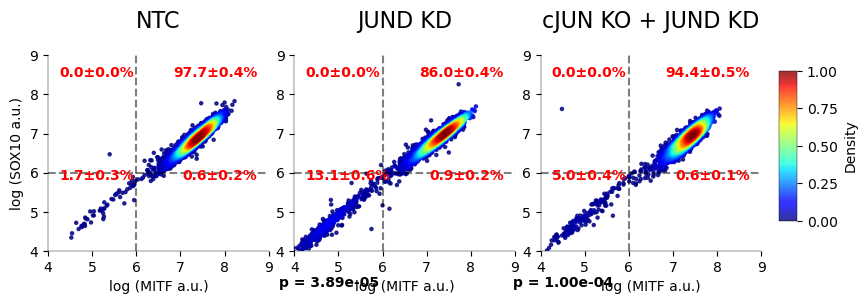

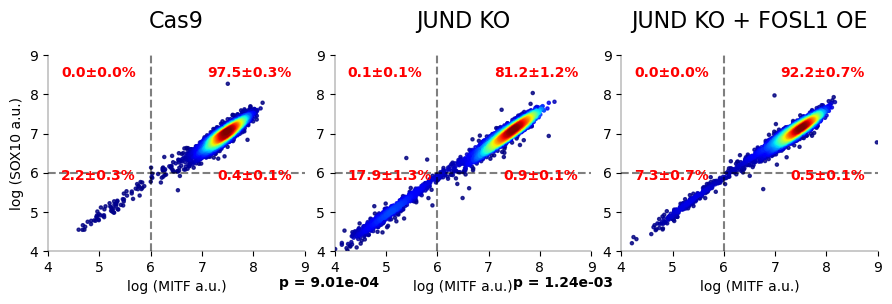

In [26]:
figure_conditions = {
    'Figure1': ['NTC', 'JUND KD', 'cJUN KO + JUND KD'],
    'Figure2': ['Cas9', 'JUND KO', 'JUND KO + FOSL1 OE']
}

# Run the plotting
results = plot_perturbation_flow_cytometry_v3(
    df=df_clean_shRNA_1_sampled,
    figure_conditions=figure_conditions,
    figsize=(9,3),
    x_column='MITF',
    y_column='SOX10', 
    condition_col='Cell_line_name',
    replicate_col='Replicate_id',
    x_gate=6.0,
    y_gate=6.0,
    save_pdf=True,
    
)

#### Exploratory

In [ ]:
#print unique cell lines
print(df_clean_shRNA_1_rename['Cell_line_name'].unique())


In [ ]:
from scipy.ndimage import uniform_filter1d

def _finite_numeric(a):
    x = pd.to_numeric(np.asarray(a).ravel(), errors='coerce')
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def _bin_edges_for_protein(x, bin_method, fine=False):
    x = _finite_numeric(x)
    if x.size == 0:
        return np.array([0.0, 1.0])
    vmin, vmax = x.min(), x.max()
    if vmin == vmax:
        eps = 0.1
        return np.array([vmin - eps, vmin, vmin + eps])
    if fine is True:
        bw = 0.02
        nb = max(1, int(np.ceil((vmax - vmin) / bw)))
        edges = vmin + bw * np.arange(nb + 1)
        if edges[-1] < vmax: edges = np.append(edges, edges[-1] + bw)
        return edges
    if isinstance(bin_method, (int, float)):
        bw = float(bin_method)
        if bw <= 0: raise ValueError("bin_method as float must be > 0")
        nb = max(1, int(np.ceil((vmax - vmin) / bw)))
        edges = vmin + bw * np.arange(nb + 1)
        if edges[-1] < vmax: edges = np.append(edges, edges[-1] + bw)
        return edges
    rule = str(bin_method).lower()
    if rule not in {'scott','fd','sturges','auto'}: rule = 'auto'
    _, edges = np.histogram(x, bins=rule)
    return edges

def plot_protein_histogram_percent(
    data, proteins, condition1='NTC', condition2='JUND KD',
    save_plot = False,
    bin_method='scott', smooth=False, show_stats=True,
    group_col='Cell_line_name', replicate_col='Replicate_id',
    ntc_color='#2E5077', jund_kd_color='#DB4C77'
):
    # Validate proteins
    missing_proteins = [p for p in proteins if p not in data.columns]
    if missing_proteins:
        raise ValueError(f"Proteins not found in data: {missing_proteins}")
    
    fig, axes = plt.subplots(1, len(proteins), figsize=(32, 8), sharey=True)
    if len(proteins) == 1: axes = [axes]

    # Cosmetic global x-lims across panels
    all_values = np.concatenate([_finite_numeric(data[p].values) for p in proteins]) if proteins else np.array([])
    x_min, x_max = (all_values.min(), all_values.max()) if all_values.size else (0.0, 1.0)

    # First pass: find ymax once (with smoothing + renorm when requested)
    ymax_raw = 0.0
    for p in proteins:
        edges = _bin_edges_for_protein(data[p].values, bin_method, fine=(smooth is True))
        for rep in data[replicate_col].dropna().unique():
            for cond in (condition1, condition2):
                x = _finite_numeric(data.loc[(data[group_col]==cond) & (data[replicate_col]==rep), p].values)
                if x.size == 0: continue
                counts, _ = np.histogram(x, bins=edges)
                pct = 100.0 * counts / x.size
                if isinstance(smooth, int) and smooth > 1:
                    pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                    s = pct.sum()
                    if s > 0: pct *= (100.0 / s)
                if pct.size: ymax_raw = max(ymax_raw, pct.max())
    ymax = 1.1 * ymax_raw if ymax_raw > 0 else 10.0  # single 10% padding

    # Dynamic legend info
    nrep1 = data.loc[data[group_col]==condition1, replicate_col].nunique()
    nrep2 = data.loc[data[group_col]==condition2, replicate_col].nunique()

    # Second pass: plot
    for idx, protein in enumerate(proteins):
        ax = axes[idx]
        edges = _bin_edges_for_protein(data[protein].values, bin_method, fine=(smooth is True))
        centers = (edges[:-1] + edges[1:]) / 2

        # Condition 1 replicates
        d1 = data.loc[data[group_col]==condition1, [replicate_col, protein]].dropna()
        for rep, sub in d1.groupby(replicate_col):
            x = _finite_numeric(sub[protein].values)
            if x.size == 0: continue
            counts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * counts / x.size
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0: pct *= (100.0 / s)
            if smooth:
                ax.plot(centers, pct, color=ntc_color, alpha=0.8, lw=3)
            else:
                ax.plot(centers, pct, color=ntc_color, alpha=0.8, lw=3, drawstyle='steps-mid')

        # Condition 2 replicates
        d2 = data.loc[data[group_col]==condition2, [replicate_col, protein]].dropna()
        for rep, sub in d2.groupby(replicate_col):
            x = _finite_numeric(sub[protein].values)
            if x.size == 0: continue
            counts, _ = np.histogram(x, bins=edges)
            pct = 100.0 * counts / x.size
            if isinstance(smooth, int) and smooth > 1:
                pct = uniform_filter1d(pct, size=smooth, mode='nearest')
                s = pct.sum()
                if s > 0: pct *= (100.0 / s)
            if smooth:
                ax.plot(centers, pct, color=jund_kd_color, alpha=0.8, lw=3)
            else:
                ax.plot(centers, pct, color=jund_kd_color, alpha=0.8, lw=3, drawstyle='steps-mid')

        # Replicate-aware stats (avoid pooled-cell t-test)
        if show_stats:
            rep_meds_1 = d1.groupby(replicate_col)[protein].median()
            rep_meds_2 = d2.groupby(replicate_col)[protein].median()
            if rep_meds_1.size > 1 and rep_meds_2.size > 1:
                _, p = stats.ttest_ind(rep_meds_1, rep_meds_2, equal_var=False)
                stars = '***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
                ax.text(0.98, 0.95, stars, transform=ax.transAxes, ha='right', va='top',
                        fontsize=32, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # Styling
        ax.set_xlabel(f'log({protein} (a.u.)')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, ymax)
        #ax.grid(axis='y', linestyle='--', alpha=0.2)
        if idx == 0: ax.set_ylabel('% cells')
        for spine in ax.spines.values(): spine.set_linewidth(2)
        ax.tick_params(width=2, length=6)

    # Legend
    handles = [
        plt.Line2D([0], [0], color=ntc_color, lw=3, label=f'{condition1} (n={nrep1})'),
        plt.Line2D([0], [0], color=jund_kd_color, lw=3, label=f'{condition2} (n={nrep2})')
    ]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    # save figure as 300 dpi pdf
    if save_plot:
        figure_title = f'Histogram {condition1} vs {condition2} bin = {bin_method}'
        fig.savefig(f'{figure_title}.pdf', dpi=300, bbox_inches='tight', pad_inches=0.2)
    return fig


# 1. Histogram with Scott's rule for bin width (recommended)
fig = plot_protein_histogram_percent(
    df_clean_shRNA_1_sampled, 
    ['JUND','FRA2','cJUN','FRA1','cFOS'],
    condition1='NTC', 
    condition2='JUND KD',
    bin_method=0.1,
    smooth=3,
    save_plot=True,  # or 'fd', 'sturges', or a fixed value like 0.1
    show_stats=False  # Since showing individual replicates
)


In [ ]:
# print all the unique cell lines
print(df_clean_shRNA_1_sampled['Cell_line_name'].unique())

In [ ]:
# Filter the dataframe for the specified cell lines
cell_lines_of_interest = ['WT', 'FOS_B8S KO', 'FOS_D8S KO', 'FOS_B8S KO + JUND KD', 'FOS_D8S KO + JUND KD', 'JUND KD']
filtered_df = df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'].isin(cell_lines_of_interest)]

# Calculate FRA2/FRA1 ratio for each cell
filtered_df['FRA2_FRA1_ratio'] = filtered_df['FRA2'] / filtered_df['FRA1']

# Group by cell line and calculate mean and SEM

# Group by cell line and calculate statistics
result = []
for cell_line in cell_lines_of_interest:
    subset = filtered_df[filtered_df['Cell_line_name'] == cell_line]
    
    # Calculate mean ratio
    mean_ratio = subset['FRA2_FRA1_ratio'].mean()
    
    # Calculate SEM (standard error of the mean)
    n = len(subset)
    sem = subset['FRA2_FRA1_ratio'].std() / np.sqrt(n)
    
    result.append({
        'Cell_line_name': cell_line,
        'Mean_FRA2_FRA1_ratio': mean_ratio,
        'SEM': sem,
        'n': n
    })

# Convert to DataFrame for easier plotting
result_df = pd.DataFrame(result)



plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Cell_line_name', y='Mean_FRA2_FRA1_ratio', data=result_df, 
                 order=cell_lines_of_interest, palette='muted')

# Set y-axis to log scale
ax.set_yscale('log')

# Add error bars
for i, row in enumerate(result_df.itertuples()):
    ax.errorbar(i, row.Mean_FRA2_FRA1_ratio, yerr=row.SEM, fmt='none', color='black', capsize=5)

# Customize the plot
plt.title('FRA2/FRA1 Ratio Across Cell Lines', fontsize=14)
plt.xlabel('Cell Line', fontsize=12)
plt.ylabel('Mean FRA2/FRA1 Ratio (log scale)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add sample size as text on each bar
for i, row in enumerate(result_df.itertuples()):
    # Place text at 2% above the bottom of the log scale
    min_y = ax.get_ylim()[0]
    text_y = min_y * 1.02
    ax.text(i, text_y, f'n={row.n}', ha='center', color='white', fontweight='bold')

# Show the plot
plt.show()

# Print the numerical results
print(result_df[['Cell_line_name', 'Mean_FRA2_FRA1_ratio', 'SEM', 'n']])

In [ ]:
# Define control conditions and experimental conditions
control_conditions = ['NTC', 'Cas9 + NTC', 'Cas9 KO + NTC']
primary_condition = 'JUND KD'  # The main condition to compare against control
other_conditions = ['JUN KO + JUND KD', 'JUND KO + FOSL1 OE', 
                   'FOS_B8S KO + JUND KD', 'FOS_D8S KO + JUND KD']

# Combined conditions list for plotting
conditions = ['Control', primary_condition] + other_conditions

# Create a combined Control group from the specified conditions
control_df = df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'].isin(control_conditions)]
control_df['Cell_line_name'] = 'Control'  # Assign all control samples to 'Control' group

# Combine the control dataframe with the rest of the data
combined_df = pd.concat([
    control_df,
    df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'] == primary_condition],
    df_clean_shRNA_1_sampled[df_clean_shRNA_1_sampled['Cell_line_name'].isin(other_conditions)]
])

# Calculate FRA2 > 6 percentages at the replicate level
fra2_percentages = {}
replicate_counts = {}  # Store the number of cells per replicate for reference

for condition in conditions:
    fra2_percentages[condition] = []
    replicate_counts[condition] = []
    condition_df = combined_df[combined_df['Cell_line_name'] == condition]
    
    # Get unique replicate IDs
    replicate_ids = condition_df['Replicate_id'].unique()
    
    for rep_id in replicate_ids:
        rep_df = condition_df[condition_df['Replicate_id'] == rep_id]
        if len(rep_df) > 0:
            total_cells = len(rep_df)
            fra2_high_count = len(rep_df[rep_df['FRA2'] > 6])
            percentage = (fra2_high_count / total_cells) * 100
            fra2_percentages[condition].append(percentage)
            replicate_counts[condition].append(total_cells)

# Calculate average percentages and SEM for plotting
avg_percentages = []
sem_values = []

for condition in conditions:
    percentages = fra2_percentages[condition]
    if percentages:
        avg_percentages.append(np.mean(percentages))
        sem_values.append(stats.sem(percentages))
    else:
        avg_percentages.append(0)
        sem_values.append(0)
        print(f"Warning: No data for condition '{condition}'")

# Perform statistical tests
# 1. Control vs JUND KD
# 2. JUND KD vs each other condition
p_values = []
significance = []

# First comparison: Control vs JUND KD
control_data = fra2_percentages['Control']
jund_kd_data = fra2_percentages[primary_condition]

if len(control_data) >= 2 and len(jund_kd_data) >= 2:
    # Using t-test for independent samples
    stat, p = stats.ttest_ind(control_data, jund_kd_data, equal_var=False)
    
    # Determine significance for Control vs JUND KD
    if p < 0.001:
        control_vs_jund_significance = '***'
    elif p < 0.01:
        control_vs_jund_significance = '**'
    elif p < 0.05:
        control_vs_jund_significance = '*'
    else:
        control_vs_jund_significance = 'ns'
    
    control_vs_jund_pvalue = p
else:
    control_vs_jund_significance = 'ns'
    control_vs_jund_pvalue = 1.0

# Second set of comparisons: JUND KD vs each other condition
for condition in other_conditions:
    condition_data = fra2_percentages[condition]
    
    if len(jund_kd_data) >= 2 and len(condition_data) >= 2:
        # Using t-test for independent samples
        stat, p = stats.ttest_ind(jund_kd_data, condition_data, equal_var=False)
        p_values.append(p)
        
        # Determine significance level
        if p < 0.001:
            significance.append('***')
        elif p < 0.01:
            significance.append('**')
        elif p < 0.05:
            significance.append('*')
        else:
            significance.append('ns')
    else:
        p_values.append(1.0)
        significance.append('ns')

# Create the bar plot with improved comparison lines
plt.figure(figsize=(10, 8))
bars = plt.bar(conditions, avg_percentages, color='skyblue', edgecolor='black', 
               yerr=sem_values, capsize=10, error_kw={'elinewidth': 2, 'capthick': 2})

# Add percentage labels in the middle of each bar
for bar, percentage in zip(bars, avg_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, percentage/2,
             f'{percentage:.1f}%', 
             ha='center', va='center', 
             fontweight='bold', fontsize=16, 
             color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# Calculate the maximum height for proper spacing
max_height = max(np.array(avg_percentages) + np.array(sem_values))
y_top = max_height * 1.3  # Space above the highest bar

# Define the vertical positions for each comparison line
line_base = max_height * 1.1  # Start position above the highest bar
line_spacing = max_height * 0.1  # Space between lines

# 1. Add comparison line for Control vs JUND KD (highest line)
line_y = line_base + line_spacing * 4
plt.plot([0, 1], [line_y, line_y], 'k-', linewidth=1.5)  # Thinner line is cleaner
plt.text(0.5, line_y + max_height * 0.02, control_vs_jund_significance, 
         ha='center', va='bottom', fontsize=14, fontweight='bold')

# 2. Add comparison lines for JUND KD vs other conditions (staggered heights)
for i, (sig, condition) in enumerate(zip(significance, other_conditions)):
    idx = i + 2  # Index of the current condition (i+2 because conditions start at index 2)
    line_y = line_base + line_spacing * (3 - i)  # Stagger the lines
    plt.plot([1, idx], [line_y, line_y], 'k-', linewidth=1.5)
    plt.text((1 + idx) / 2, line_y + max_height * 0.02, sig, 
             ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add labels and title
plt.xlabel('Conditions')
plt.ylabel('Percentage of FRA2 high cells (%)')
#plt.title('Average Percentage of Cells with FRA2 > 6 by Condition (with SEM)', fontweight='bold')

# Customize x-axis
plt.xticks(rotation=45, ha='right')

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add grid for better readability
# plt.grid(axis='y', linestyle='--', alpha=0.3)

# Set y-axis limits with enough space for comparison lines
plt.ylim(0, line_base + line_spacing * 5)

# # Add a note about significance levels
# plt.figtext(0.01, 0.01, "* p<0.05, ** p<0.01, *** p<0.001, ns: not significant", ha="left", fontsize=10)

plt.tight_layout()
# save as high res pdf
plt.savefig(f'FRA2_percentage_bar_plot_COLO858_JUND_KD_experiment.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n--- Detailed Statistics ---")
print(f"Control vs {primary_condition}: p={control_vs_jund_pvalue:.4f} {control_vs_jund_significance}")

print(f"\n{primary_condition} vs other conditions:")
for i, condition in enumerate(other_conditions):
    print(f"{primary_condition} vs {condition}: p={p_values[i]:.4f} {significance[i]}")

print("\nCondition | Average % | SEM | # of Replicates")
print("-" * 60)
for i, condition in enumerate(conditions):
    print(f"{condition:<20} | {avg_percentages[i]:>8.1f}% | {sem_values[i]:>6.2f} | {len(fra2_percentages[condition])}")